# The Call Graph Protocol

[Official documentation](https://qualtran.readthedocs.io/en/latest/resource_counting/call_graph.html)

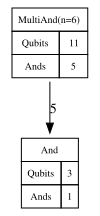

In [1]:
from qualtran.drawing import show_call_graph, show_counts_sigma
from qualtran.bloqs.mcmt import MultiAnd, And

bloq = MultiAnd(cvs=(1,)*6)
show_call_graph(bloq)

### Interface

In [3]:
graph, sigma = bloq.call_graph()
print(graph)

DiGraph with 2 nodes and 1 edges


In [4]:
And().bloq_counts()

{}

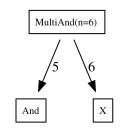

#### Counts totals:
 - `And`: 5
 - `X`: 6

In [5]:
graph, sigma = MultiAnd(cvs=(1,0)*3).call_graph()
show_call_graph(graph)
show_counts_sigma(sigma)
# X is pauli gate

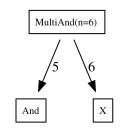

#### Counts totals:
 - `And`: 5
 - `X`: 6

In [6]:
from qualtran.resource_counting import SympySymbolAllocator
import attrs

ssa = SympySymbolAllocator()
cv1 = ssa.new_symbol('cv1')
cv2 = ssa.new_symbol('cv2')

def ignore_cv(bloq):
    if isinstance(bloq, And):
        return attrs.evolve(bloq, cv1=cv1, cv2=cv2)
    
    return bloq

graph, sigma = MultiAnd(cvs=(1,0)*3).call_graph(generalizer=ignore_cv)
show_call_graph(graph)
show_counts_sigma(sigma)

### Additional Functionality

### Implementation

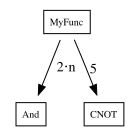

In [8]:
from functools import cached_property
from typing import Dict, Optional, Set, Union

from attrs import frozen

from qualtran import Bloq, BloqBuilder, Register, Side, Signature, SoquetT
from qualtran.resource_counting import BloqCountT, SympySymbolAllocator

import sympy

from qualtran.bloqs.basic_gates import CNOT

@frozen
class MyFunc(Bloq):
    n: Union[int, sympy.Expr]

    @cached_property
    def signature(self) -> "Signaure":
        return Signature.build(x=self.n)

    def build_call_graph(self, ssa: "SympySymbolAllocator") -> Set["BloqCountT"]:
        return {
            (And(), 2*self.n),
            (CNOT(), 5),
        }

myfunc = MyFunc(n=sympy.sympify("n"))
graph, sigma = myfunc.call_graph()
show_call_graph(graph)

### Default Fallback

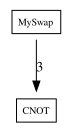

#### Counts totals:
 - `CNOT`: 3

In [10]:
@frozen
class MySwap(Bloq):

    @cached_property
    def signature(self) -> "Signature":
        return Signature.build(q0=1, q1=1)

    def build_composite_bloq(self, bb, q0, q1):
        q0, q1 = bb.add(CNOT(), ctrl=q0, target=q1)
        q1, q0 = bb.add(CNOT(), ctrl=q1, target=q0)
        q0, q1 = bb.add(CNOT(), ctrl=q0, target=q1)
        return {"q0": q0, "q1": q1}

graph, sigma = MySwap().call_graph()
show_call_graph(graph)
show_counts_sigma(sigma)